## Preprocessing

In [ ]:
import scanpy as sc
import blend
import anndata

adata = sc.read_h5ad('./GSM9046248_Embryo_E8.0_stereo_rep2_spatial.h5ad')
sc_adata = sc.read_h5ad('./scRNA_seq_E80.h5ad')
adata = adata.raw.to_adata()

adata = blend.data_process(adata, tar_sum=1e4)
sc_adata = blend.data_process(sc_adata, tar_sum=1e4)
adata, sc_adata = blend.select_common_genes(adata, sc_adata)

adata: Normalize and log1p
adata: Normalize and log1p
Number of common genes: 12298
adata shape after filtering: (27266, 12298)
sc_adata shape after filtering: (16681, 12298)


In [ ]:
data, W_initial, H_initial, sc_reference, V_initial, Similarity_matrix, rank = blend.BLEND_fit(spatial_data=adata, sc_data=sc_adata, setrank=0, spa_k=20, exp_k=15, device="cuda:0")

/home/lixuan/miniconda3/envs/blend_demo/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/lixuan/program/code_organization/BLEND_main/blend/main.py:16: ImplicitModificationWarning: Setting element `.obsm['X_norm']` of view, initializing view as actual.
  sc_data.obsm['X_norm'] = median_normalize(sc_data.X)


Iter 0: cost=119555160.000000, improvement=inf
Iter 50: cost=76919040.000000, improvement=192200.000000
Training finished in 10.11 seconds.


## Model

In [ ]:
result = blend.fit(data, W_initial, H_initial, V_initial, Similarity_matrix, P=sc_reference, lamb=5, alpha=13, rank=rank, weight=0.3, max_iter=1500, device="cuda:0")
W = result['W']

Iter 0: cost=115015688.000000, improvement=inf
Iter 50: cost=47132752.000000, improvement=32396.000000
Iter 100: cost=46602840.000000, improvement=9104.000000
Iter 150: cost=46099716.000000, improvement=9728.000000
Iter 200: cost=45702144.000000, improvement=6028.000000
Iter 250: cost=45448864.000000, improvement=4376.000000
Iter 300: cost=45262276.000000, improvement=3184.000000
Iter 350: cost=45120572.000000, improvement=2592.000000
Iter 400: cost=44998252.000000, improvement=2320.000000
Iter 450: cost=44887644.000000, improvement=2116.000000
Iter 500: cost=44787048.000000, improvement=1924.000000
Iter 550: cost=44695640.000000, improvement=1736.000000
Iter 600: cost=44613344.000000, improvement=1552.000000
Iter 650: cost=44539852.000000, improvement=1384.000000
Iter 700: cost=44474400.000000, improvement=1240.000000
Iter 750: cost=44416048.000000, improvement=1096.000000
Iter 800: cost=44363912.000000, improvement=988.000000
Iter 850: cost=44317192.000000, improvement=888.000000
Ite

After obtaining the factorization results W (the low-dimensional cell embedding matrix), you can run BLEND’s leiden_cluster function to derive the clustering results and UMAP embeddings from the W matrix.

In [ ]:
cluster, X_umap = blend.blend_leiden_cluster(W, adata,
    resolution = 1.55,
    n_neighbors = 30,
    n_pcs = 30,
    log1p = True,
    svd_solver = "arpack",
)

In [ ]:
adata.obs['blend'] = cluster
adata.obsm['X_umap'] = X_umap

## Visualization

In [ ]:
custom_colors = ['#3ab5b3','#954f97','#b3d5f1','#f0686c','#5567b1','#80c66d','#8370fe','#1e90ff','#228b22','#ffb90f','#fe0000','#ff7f00','#8b864e','#eaf0b2','#f7d8d6','#c4c2da','#8a8a88','#d8a266','#b86078','#39b086',"#3467a1","#345201","#ebe5c2", "#D57358", "#023047", "#F7CA71", "#1697a6", "#8bc6cc", "#C9DEC3","#169820","#161898"]     

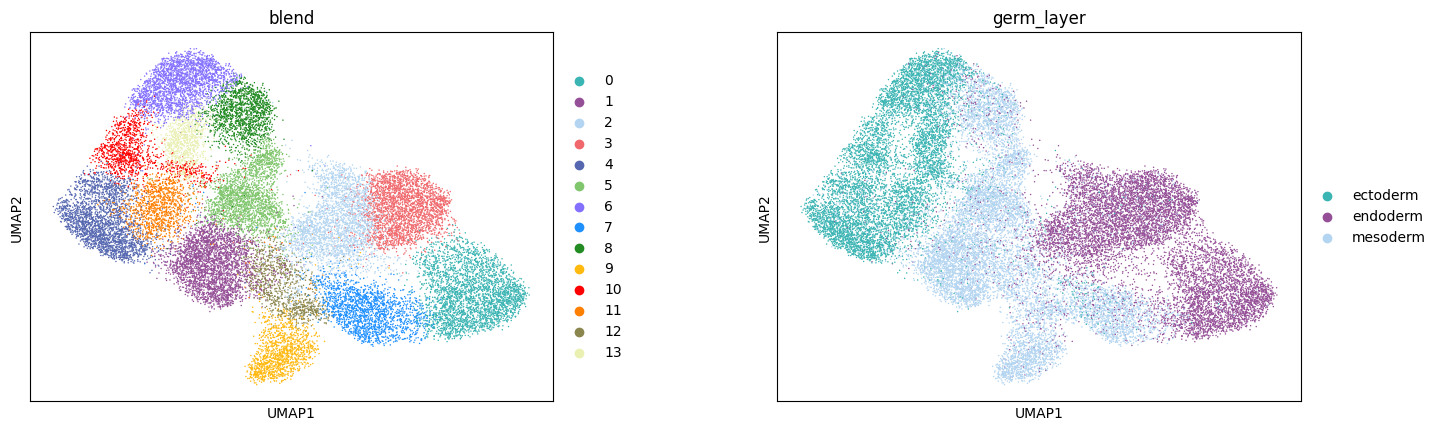

In [ ]:
sc.pl.umap(adata, color=['blend','germ_layer'], palette=custom_colors, legend_loc='right margin', wspace = 0.3)

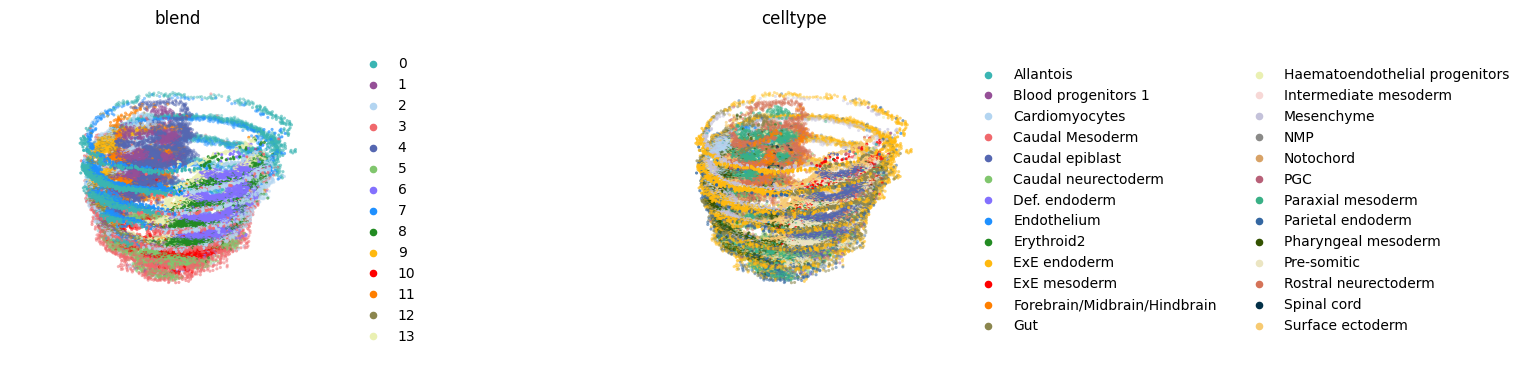

In [ ]:
sc.pl.embedding(adata, basis='spatial', color=['blend', 'celltype'], palette=custom_colors, frameon=False, size=0.5, ncols=7, projection='3d')